II. Exploratory Data Analysis (EDA) for Track 2

In [ ]:
!pip install -q pandas numpy matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.max_colwidth", 200)
RANDOM_STATE = 0

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
DATA_FILE = "/content/drive/MyDrive/dl4nlp/trial_data_multiple_choice.tsv"

df = pd.read_csv(DATA_FILE, sep="\t")

print("✅ Data loaded. Shape:", df.shape)
display(df.head())


Mounted at /content/drive
✅ Data loaded. Shape: (148, 5)


,index,lang_reg,question,multiple_choice_options,correct_answer
0,1,ms-SG,Apakah akronim lazim untuk flat perumahan awam di mana majoriti rakyat Singapura tinggal?,DBS\nHPB\nHDB\nSAF,HDB
1,2,ms-SG,Parti politik manakah yang telah menjadi parti pemerintah Singapura sejak tahun 1959?,Parti Pekerja (WP) \nParti Tindakan Rakyat (PAP) \nParti Demokratik Singapura (SDP) \nParti Kemajuan Singapura (PSP),Parti Tindakan Rakyat (PAP)
2,3,ms-SG,"Apakah maskot rasmi Singapura, iaitu makhluk mitos berkepala singa dan berbadan ikan?",Merlion \nSinga Kesopanan (Singa The Courtesy Lion) \nMemerang Asia \nVanda Miss Joaquim,Merlion
3,4,ms-SG,"Apakah nama lapangan terbang antarabangsa utama Singapura, yang sering diundi sebagai salah sebuah lapangan terbang yang terbaik di dunia?",Lapangan Terbang Seletar \nLapangan Terbang Changi \nLapangan Terbang Paya Lebar \nLapangan Terbang Marina Bay,Lapangan Terbang Changi
4,5,ms-SG,Singapura menyambut Hari Kebangsaan setiap tahun pada bulan apa?,Februari \nJulai \nSeptember \nOgos,Ogos


In [ ]:
print("DataFrame info:")
print(df.info())

print("\nFirst 5 random rows:")
display(df.sample(5, random_state=RANDOM_STATE))

print("\nMissing values per column:")
print(df.isna().sum())

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   index                    148 non-null    int64 
 1   lang_reg                 148 non-null    object
 2   question                 148 non-null    object
 3   multiple_choice_options  148 non-null    object
 4   correct_answer           148 non-null    object
dtypes: int64(1), object(4)
memory usage: 5.9+ KB
None

First 5 random rows:


,index,lang_reg,question,multiple_choice_options,correct_answer
24,25,es-EC,¿Qué nombre recibe Ecuador por su diversidad geográfica y cultural?,El país de los volcanes\nEl país de los cuatro mundos\nLa mitad del mundo\nEl corazón de Sudamérica,El país de los cuatro mundos
7,8,ta-SG,சிங்கப்பூரர்களில் பெரும்பாலோர் வசிக்கும் பொது வீடுகளின் பொதுவான சுருக்கம் சொல் என்ன?,DBS\nHPB\nHDB\nSAF,HDB
37,38,zh-CN,4. 中国的“端午节”通常是为了纪念哪位古代文学家？,杜牧\n苏轼\n屈原\n白居易,屈原
114,115,ga-IE,Cé acu duine is dornálaí Éireannach cáiliúil?,Katie Taylor\nMichelle O’Neill\nAndrea Corr\nSusan Jones,Katie Taylor
27,28,es-EC,¿Qué ciudad ecuatoriana fue declarada Patrimonio Cultural de la Humanidad por la UNESCO en 1978?,Guayaquil\nCuenca\nQuito\nLoja,Quito



Missing values per column:
index                      0
lang_reg                   0
question                   0
multiple_choice_options    0
correct_answer             0
dtype: int64


In [ ]:
before = df.shape[0]
df = df.dropna(subset=["question", "correct_answer"]).copy()
after = df.shape[0]
print(f"Dropped {before - after} rows with missing question or correct_answer.")

if df["lang_reg"].isna().any():
    missing_lang = df["lang_reg"].isna().sum()
    print(f"Found {missing_lang} rows with missing lang_reg. Filling with 'unknown'.")
    df["lang_reg"] = df["lang_reg"].fillna("unknown")

Dropped 0 rows with missing question or correct_answer.


Number of options per question:
num_options
4    146
3      2
Name: count, dtype: int64


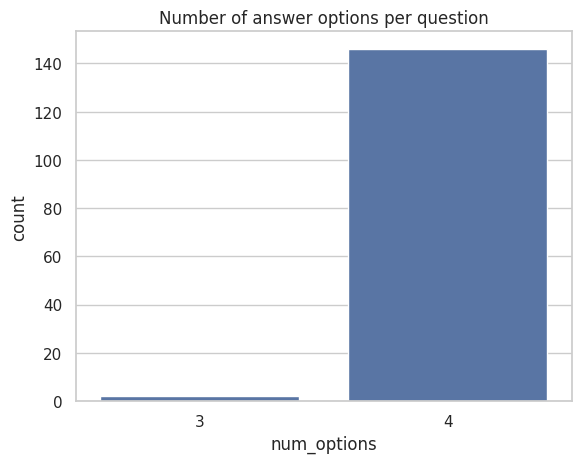


Is correct_answer among options?
correct_in_options
True     146
False      2
Name: count, dtype: int64

Rows with inconsistent labels or non-4 options: 4


,index,lang_reg,question,multiple_choice_options,correct_answer,options_list,num_options,correct_in_options
11,12,ta-SG,சிங்கப்பூர் ஒவ்வோர் ஆண்டும் எந்த மாதத்தில் தங்களது தேசிய தினத்தைக் கொண்டாடுகிறது?,பிப்ரவரி \nஜூலை \nசெப்டம்பர் \nஆகஸ்ட,ஆகஸ்ட்,"[பிப்ரவரி, ஜூலை, செப்டம்பர், ஆகஸ்ட]",4,False
44,45,es-MX,¿Cuáles son los colores de la bandera del país?,"Verde, Amarillo, Rojo\nVerde, Blanco, Rojo\nBlanco, Rojo, Cafe","Verde, Blanco, Rojo","[Verde, Amarillo, Rojo, Verde, Blanco, Rojo, Blanco, Rojo, Cafe]",3,True
48,49,es-MX,¿Cual es la comida callejera más típica en el país?,Atun\nHot Dogs\nTacos,Tacos,"[Atun, Hot Dogs, Tacos]",3,True
98,99,eu-ES,Zein da Euskal Herriko kirol tradizional ezagunena?,Esku-pilota\nFutbola\nSaskibaloia\nHockeya,Esku-pilota / Hand-ball,"[Esku-pilota, Futbola, Saskibaloia, Hockeya]",4,False



After cleaning inconsistent rows:
Original shape: (148, 8)  -> Cleaned shape: (144, 8)


In [ ]:
def split_options(s):
    """
    Split the multiple_choice_options field (newline-separated)
    into a list of clean option strings.
    """
    if pd.isna(s):
        return []
    return [opt.strip() for opt in str(s).split("\n") if opt.strip()]

df["options_list"] = df["multiple_choice_options"].apply(split_options)
df["num_options"] = df["options_list"].str.len()

print("Number of options per question:")
print(df["num_options"].value_counts())
plt.figure()
sns.countplot(x="num_options", data=df)
plt.title("Number of answer options per question")
plt.xlabel("num_options")
plt.show()

def correct_in_options(row):
    return row["correct_answer"].strip() in row["options_list"]

df["correct_in_options"] = df.apply(correct_in_options, axis=1)
print("\nIs correct_answer among options?")
print(df["correct_in_options"].value_counts())

problematic = df[~df["correct_in_options"] | (df["num_options"] != 4)]
print(f"\nRows with inconsistent labels or non-4 options: {problematic.shape[0]}")
if not problematic.empty:
    display(problematic.head())

df_clean = df[(df["correct_in_options"]) & (df["num_options"] == 4)].copy()
print("\nAfter cleaning inconsistent rows:")
print("Original shape:", df.shape, " -> Cleaned shape:", df_clean.shape)


Questions per language–region:


,count
lang_reg,
es-EC,8
fr-FR,8
tl-PH,8
ar-SA,7
ar-MA,7
zh-SG,7
ms-SG,7
ja-JP,7
ta-LK,7


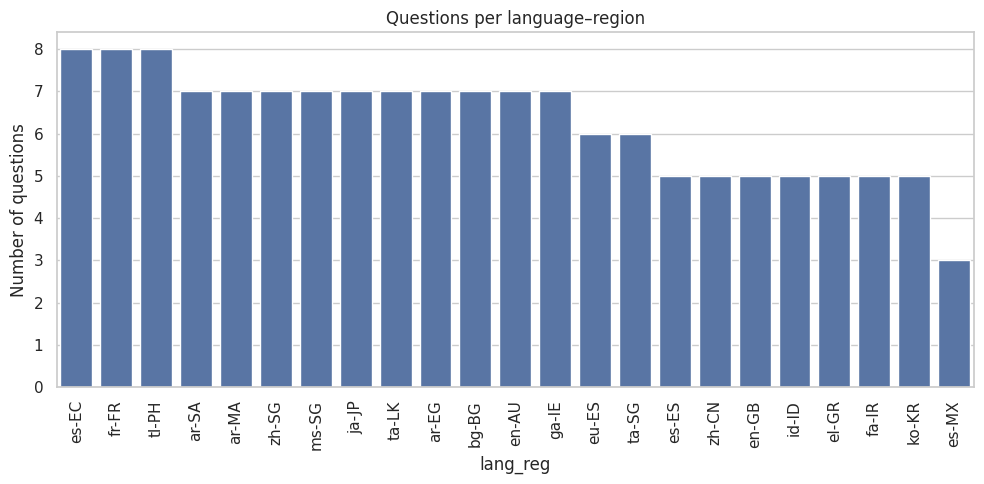

In [ ]:
lang_counts = df_clean["lang_reg"].value_counts().sort_values(ascending=False)
print("Questions per language–region:")
display(lang_counts)

plt.figure(figsize=(10, 5))
sns.barplot(x=lang_counts.index, y=lang_counts.values)
plt.xticks(rotation=90)
plt.ylabel("Number of questions")
plt.title("Questions per language–region")
plt.tight_layout()
plt.show()

Basic stats for question/answer lengths (words):


,question_len_words,answer_len_words
count,144.000000,144.000000
mean,8.347222,2.013889
std,4.751620,1.472290
min,1.000000,1.000000
25%,5.000000,1.000000
50%,8.000000,2.000000
75%,11.000000,2.000000
max,26.000000,10.000000


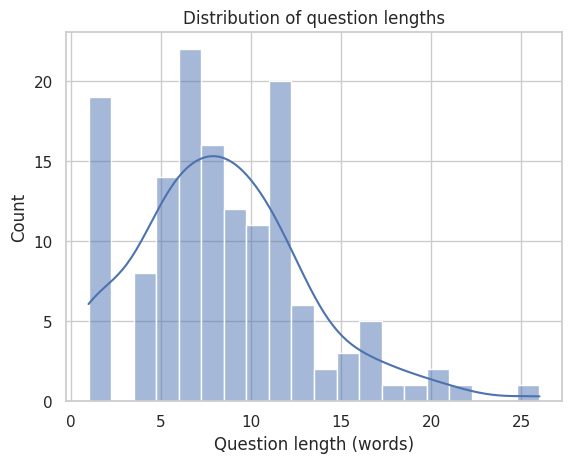

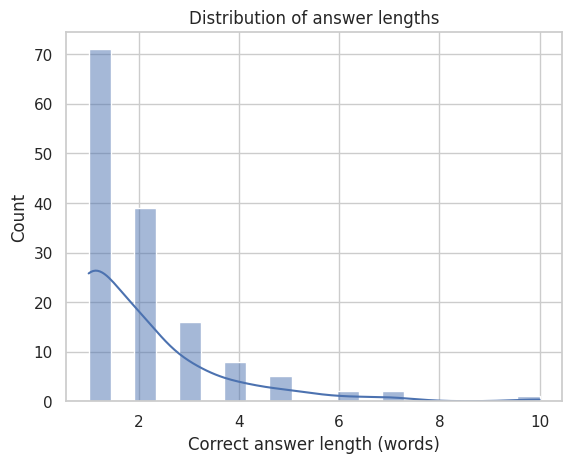

In [ ]:
df_clean["question_len_chars"] = df_clean["question"].str.len()
df_clean["question_len_words"] = df_clean["question"].str.split().str.len()

df_clean["answer_len_chars"] = df_clean["correct_answer"].str.len()
df_clean["answer_len_words"] = df_clean["correct_answer"].str.split().str.len()

print("Basic stats for question/answer lengths (words):")
display(df_clean[["question_len_words", "answer_len_words"]].describe())

plt.figure()
sns.histplot(df_clean["question_len_words"], bins=20, kde=True)
plt.xlabel("Question length (words)")
plt.title("Distribution of question lengths")
plt.show()

plt.figure()
sns.histplot(df_clean["answer_len_words"], bins=20, kde=True)
plt.xlabel("Correct answer length (words)")
plt.title("Distribution of answer lengths")
plt.show()

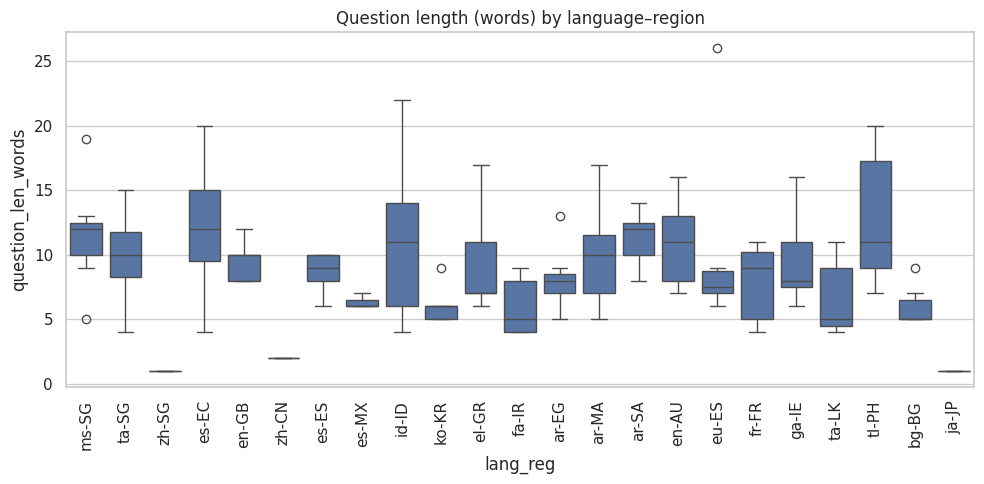

Average question length (words) by language–region:


,question_len_words
lang_reg,
ja-JP,1.000000
zh-SG,1.000000
zh-CN,2.000000
bg-BG,6.000000
fa-IR,6.000000
ko-KR,6.200000
es-MX,6.333333
ta-LK,6.714286
fr-FR,8.000000


In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x="lang_reg", y="question_len_words")
plt.xticks(rotation=90)
plt.title("Question length (words) by language–region")
plt.tight_layout()
plt.show()

q_len_by_lang = df_clean.groupby("lang_reg")["question_len_words"].mean().sort_values()
print("Average question length (words) by language–region:")
display(q_len_by_lang)

Topic distribution:


,count
topic,
other,142
celebrations,1
sports,1


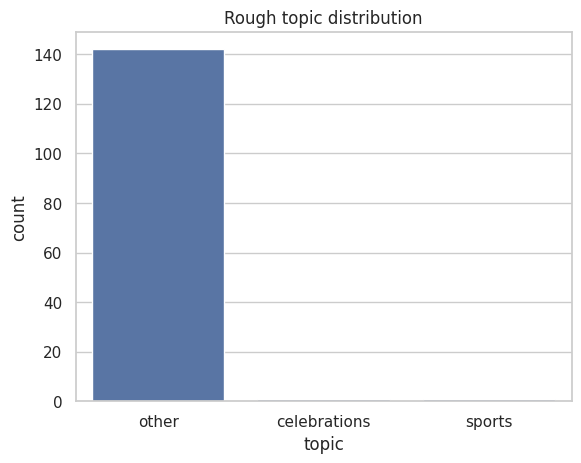


Questions per (lang_reg, topic):


topic,celebrations,other,sports
lang_reg,,,
ar-EG,0,7,0
ar-MA,0,7,0
ar-SA,0,7,0
bg-BG,0,7,0
el-GR,0,5,0
en-AU,0,6,1
en-GB,1,4,0
es-EC,0,8,0
es-ES,0,5,0


In [ ]:
def rough_topic(q):
    q_low = q.lower()
    if any(w in q_low for w in ["food", "eat", "drink", "meal", "restaurant"]):
        return "food"
    if any(w in q_low for w in ["school", "class", "teacher", "students"]):
        return "education"
    if any(w in q_low for w in ["holiday", "festival", "celebration", "holiday"]):
        return "celebrations"
    if any(w in q_low for w in ["sport", "sports", "game", "play", "team"]):
        return "sports"
    return "other"

df_clean["topic"] = df_clean["question"].apply(rough_topic)

topic_counts = df_clean["topic"].value_counts()
print("Topic distribution:")
display(topic_counts)

plt.figure()
sns.countplot(x="topic", data=df_clean,
              order=topic_counts.index)
plt.title("Rough topic distribution")
plt.show()

topic_by_lang = pd.crosstab(df_clean["lang_reg"], df_clean["topic"])
print("\nQuestions per (lang_reg, topic):")
display(topic_by_lang)


Correlation matrix:


,question_len_words,answer_len_words,num_options
question_len_words,1.000000,0.030294,NaN
answer_len_words,0.030294,1.000000,NaN
num_options,NaN,NaN,NaN


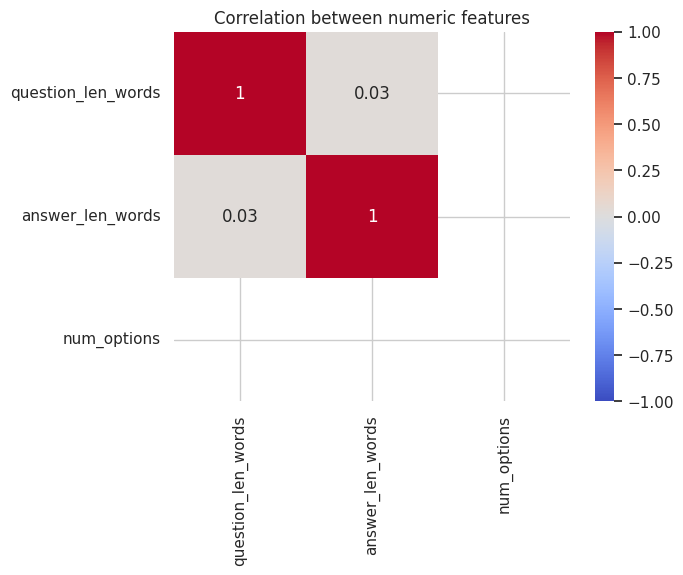

In [ ]:
numeric_cols = ["question_len_words", "answer_len_words", "num_options"]
corr = df_clean[numeric_cols].corr()
print("Correlation matrix:")
display(corr)

plt.figure()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between numeric features")
plt.show()

In [ ]:
output_file = "trial_data_multiple_choice_cleaned.tsv"
df_clean.to_csv(output_file, sep="\t", index=False)
print("Saved cleaned file as:", output_file)

Saved cleaned file as: trial_data_multiple_choice_cleaned.tsv


In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report
)

df = pd.read_csv("trial_data_multiple_choice.tsv", sep="\t")
df.head()

df["text"] = df["question"] + " " + df["multiple_choice_options"].str.replace("\n", " ")

X = df["text"]
y = df["lang_reg"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

nb_clf = MultinomialNB()
nb_clf.fit(X_train_vec, y_train)

y_pred_nb = nb_clf.predict(X_test_vec)

print("=== Multinomial Naive Bayes ===")
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Precision (macro):", precision_score(y_test, y_pred_nb, average="macro", zero_division=0))
print("Recall (macro):", recall_score(y_test, y_pred_nb, average="macro", zero_division=0))

print("\nClassification report:\n")
print(classification_report(y_test, y_pred_nb))


lr_clf = LogisticRegression(
    max_iter=1000,
    multi_class="multinomial"
)
lr_clf.fit(X_train_vec, y_train)

y_pred_lr = lr_clf.predict(X_test_vec)

print("=== Multinomial Logistic Regression ===")
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision (macro):", precision_score(y_test, y_pred_lr, average="macro", zero_division=0))
print("Recall (macro):", recall_score(y_test, y_pred_lr, average="macro", zero_division=0))

print("\nClassification report:\n")
print(classification_report(y_test, y_pred_lr))


=== Multinomial Naive Bayes ===
Confusion matrix:
 [[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0]
 [0 0 0 0 0 0 0 0 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/l

=== Multinomial Logistic Regression ===
Confusion matrix:
 [[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0]
 [0 0 0 0 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
